In [1]:
import pandas as pd  #manejo de tablas y datos 
import matplotlib.pyplot as plt  #graficos
import seaborn as sns  # mejor visualizacion
from pathlib import Path   #manejo de documentos 
import sys  #consultas con el sistema

sys.path.append(str(Path("..").resolve())) 
from scripts.cleaning import remove_duplicates, fill_missing, validate_no_nulls    #importo funciones creadas en scripts.cleaning 

print("✅ Imports listos")

✅ Imports listos


In [2]:
#CREACION DE DATASETS

# Empleados
pd.DataFrame({
    'empleado_id': range(1, 21),
    'nombre': ['Ana','Luis','Pedro','María','Carlos','Sofia','Diego',
               'Valentina','Matías','Camila','Jorge','Paula','Andrés',
               'Isabel','Roberto','Carmen','Felipe','Laura','Miguel','Rosa'],
    'depto_id': [1,2,1,3,2,1,3,2,1,3,2,1,2,3,1,2,3,1,2,3],
    'sueldo': [1500,2000,1800,2200,1900,1600,2100,1750,None,2300,
               1850,1950,2050,1700,2150,1800,None,1650,2250,1900],
    'antiguedad_anos': [2,5,3,7,4,1,6,3,2,8,4,5,3,6,7,2,4,1,9,3]
}).to_csv("../data/empleados.csv", index=False)

# Departamentos
pd.DataFrame({
    'depto_id': [1, 2, 3],
    'nombre_depto': ['Ventas', 'Tech', 'RRHH'],
    'presupuesto': [50000, 80000, 30000]
}).to_csv("../data/departamentos.csv", index=False)

print("✅ CSVs creados")

✅ CSVs creados


In [3]:
empleados = pd.read_csv("../data/empleados.csv")
departamentos = pd.read_csv("../data/departamentos.csv")

print("Empleados:")
print(empleados.head())
print("\nDepartamentos:")
print(departamentos)

Empleados:
   empleado_id  nombre  depto_id  sueldo  antiguedad_anos
0            1     Ana         1  1500.0                2
1            2    Luis         2  2000.0                5
2            3   Pedro         1  1800.0                3
3            4   María         3  2200.0                7
4            5  Carlos         2  1900.0                4

Departamentos:
   depto_id nombre_depto  presupuesto
0         1       Ventas        50000
1         2         Tech        80000
2         3         RRHH        30000


In [4]:
df = empleados.merge(departamentos, on='depto_id', how='left')

print(f"Después del merge: {df.shape}")
print(df.head())

Después del merge: (20, 7)
   empleado_id  nombre  depto_id  sueldo  antiguedad_anos nombre_depto  \
0            1     Ana         1  1500.0                2       Ventas   
1            2    Luis         2  2000.0                5         Tech   
2            3   Pedro         1  1800.0                3       Ventas   
3            4   María         3  2200.0                7         RRHH   
4            5  Carlos         2  1900.0                4         Tech   

   presupuesto  
0        50000  
1        80000  
2        50000  
3        30000  
4        80000  


In [5]:
print(f"Antes de limpiar — nulos: {df.isnull().sum().sum()}")

df = remove_duplicates(df)
df = fill_missing(df, strategy='median')
validate_no_nulls(df, ['nombre', 'sueldo', 'nombre_depto'])

print(f"Después de limpiar — nulos: {df.isnull().sum().sum()}")
print("✅ Datos limpios")

Antes de limpiar — nulos: 2
Después de limpiar — nulos: 0
✅ Datos limpios


In [6]:
# Métrica 1 — Nómina promedio por departamento
nomina_por_depto = df.groupby('nombre_depto')['sueldo'].mean().round(2)
print("💰 Nómina promedio por departamento:")
print(nomina_por_depto)

# Métrica 2 — Top 3 sueldos más altos
top3_sueldos = df.nlargest(3, 'sueldo')[['nombre', 'nombre_depto', 'sueldo']]
print("\n🏆 Top 3 sueldos:")
print(top3_sueldos)

# Métrica 3 — Promedio de antigüedad por departamento
antiguedad_por_depto = df.groupby('nombre_depto')['antiguedad_anos'].mean().round(1)
print("\n📅 Antigüedad promedio por departamento:")
print(antiguedad_por_depto)

💰 Nómina promedio por departamento:
nombre_depto
RRHH      2016.67
Tech      1942.86
Ventas    1792.86
Name: sueldo, dtype: float64

🏆 Top 3 sueldos:
    nombre nombre_depto  sueldo
9   Camila         RRHH  2300.0
18  Miguel         Tech  2250.0
3    María         RRHH  2200.0

📅 Antigüedad promedio por departamento:
nombre_depto
RRHH      5.7
Tech      4.3
Ventas    3.0
Name: antiguedad_anos, dtype: float64


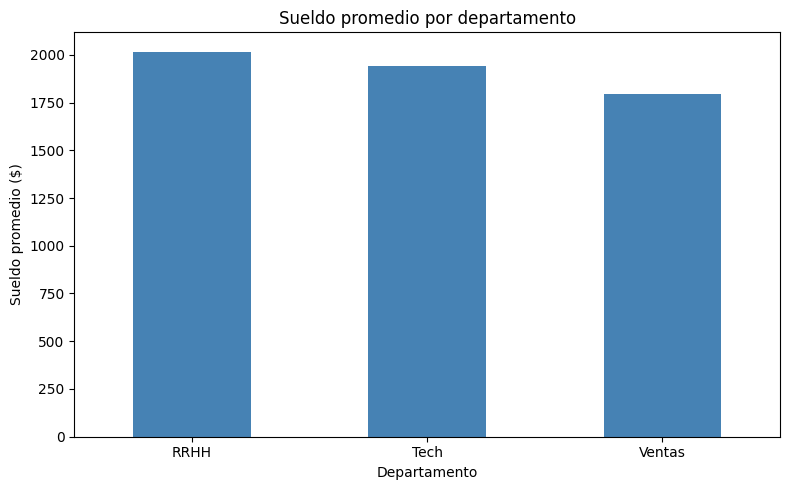

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
nomina_por_depto.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title("Sueldo promedio por departamento")
ax.set_xlabel("Departamento")
ax.set_ylabel("Sueldo promedio ($)")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("../exercises/grafico_sueldos.png")
plt.show()

/var/folders/xl/p1gq54_14gd6j3wggwjlvq440000gn/T/ipykernel_12403/2621215936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='nombre_depto', y='antiguedad_anos', ax=ax, palette='muted')


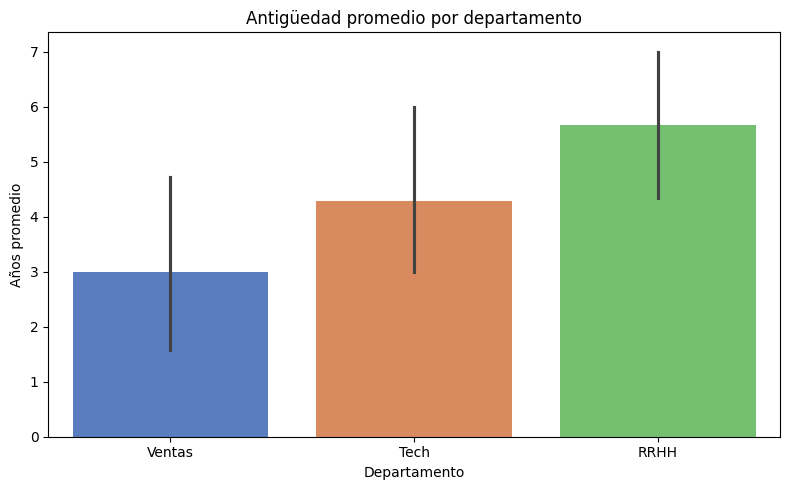

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='nombre_depto', y='antiguedad_anos', ax=ax, palette='muted')
ax.set_title("Antigüedad promedio por departamento")
ax.set_xlabel("Departamento")
ax.set_ylabel("Años promedio")
plt.tight_layout()
plt.savefig("../exercises/grafico_antiguedad.png")
plt.show()

In [9]:
excel_output = Path("../exercises/reporte_final.xlsx")

with pd.ExcelWriter(excel_output) as writer:
    # Hoja 1 — datos completos limpios
    df.to_excel(writer, sheet_name="datos_completos", index=False)
    
    # Hoja 2 — métricas por departamento
    metricas = pd.DataFrame({
        'departamento': nomina_por_depto.index,
        'sueldo_promedio': nomina_por_depto.values,
        'antiguedad_promedio': antiguedad_por_depto.values
    })
    metricas.to_excel(writer, sheet_name="metricas_depto", index=False)
    
    # Hoja 3 — top 3 sueldos
    top3_sueldos.to_excel(writer, sheet_name="top3_sueldos", index=False)

print(f"✅ Excel guardado: {excel_output}")

✅ Excel guardado: ../exercises/reporte_final.xlsx
